KNN (K-Nearest Neighbors) method

In [ ]:
In KNN(K-Nearest Neighbors), the distance metric plays a crucial role in determining the "closeness" between data points. 
It’s the method used to calculate the distance between a test point and each training point. 
The closer the points, the more influence they have on the classification or regression output.
We will use Euclidean Distance, Manhattan Distance (also called L1 norm) and Minkowski Distance in out KNN analysis
to check the classification accuracy, confusion matrix and regression error metrics.

In [13]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [14]:
# Load the dataset
df_class_model = pd.read_csv('../data/processed_data/df_delay.csv')

In [15]:
df_class_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17653 entries, 0 to 17652
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        17653 non-null  object 
 1   Time        17653 non-null  object 
 2   Day         17653 non-null  object 
 3   Station     17653 non-null  object 
 4   Code        17653 non-null  object 
 5   Min Delay   17653 non-null  float64
 6   Min Gap     17653 non-null  float64
 7   Bound       17653 non-null  object 
 8   Line        17653 non-null  object 
 9   Month       17653 non-null  int64  
 10  Month Name  17653 non-null  object 
 11  Category    17653 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.6+ MB


In [30]:
# Preprocess the data, specify X and y
X = df_class_model.drop(['Date','Time','Code'], axis=1)
y = df_class_model['Min Delay']

In [31]:
X

,Day,Station,Min Delay,Min Gap,Bound,Line,Month,Month Name,Category
0,Monday,VAUGHAN MC STATION,0.0,0.0,S,YU,1,January,Door/Passenger/Platform Incidents
1,Monday,BLOOR STATION,0.0,0.0,S,YU,1,January,Security/Policing
2,Monday,VAUGHAN MC STATION,8.0,14.0,S,YU,1,January,Miscellaneous
3,Monday,DUNDAS STATION,0.0,0.0,S,YU,1,January,Security/Policing
4,Monday,ST GEORGE YUS STATION,0.0,0.0,N,YU,1,January,Security/Policing
...,...,...,...,...,...,...,...,...,...
17648,Friday,BAYVIEW STATION,6.0,13.0,E,SHP,1,January,Mechanical/Electrical/Vehicle Equipment
17649,Friday,UNION STATION TO KING,4.0,8.0,N,YU,1,January,Door/Passenger/Platform Incidents
17650,Friday,PAPE STATION,9.0,14.0,E,BD,1,January,Security/Policing
17651,Friday,DAVISVILLE STATION,3.0,7.0,N,YU,1,January,Medical/Injury/Safety


In [32]:
# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [33]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [35]:
# Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [36]:
# Make predictions
y_pred = knn.predict(X_test)

In [37]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.4075332766921552
Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.83      0.62      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.21      0.20      0.20       469
         4.0       0.17      0.11      0.13       368
         5.0       0.14      0.08      0.10       333
         6.0       0.12      0.03      0.05       187
         7.0       0.21      0.05      0.08       126
         8.0       0.19      0.05      0.08        75
         9.0       0.00      0.00      0.00        70
        10.0       0.00      0.00      0.00        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0       0.00      0.00      0.00        18
        17.0       0.00      

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

DISCUSS THE CHANGE IN ACCURACY DUE TO CHANGES IN THE DATASET

Accuracy: 0.4075332766921552

This means that the KNN model correctly classified approximately 40.75% of the instances in the test set.

The precision, recall, and F1-scores are also not high, indicating that the model is not much effective at distinguishing between the two classes ('Min Delay' present or not). The metrics suggest that the model is slightly better at predicting class 1 ('Min Delay' present) than class 0 ('Min Delay' is not present)

Lets train the KNN model with the current k  to find the highest accuracy

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Define a range of k values to test
k_values = range(1, 21)  # Test k values from 1 to 20
accuracies = []

Use the elbow method to find the optimal value of K (the number of neighbors) by plotting accuracy versus K-values.

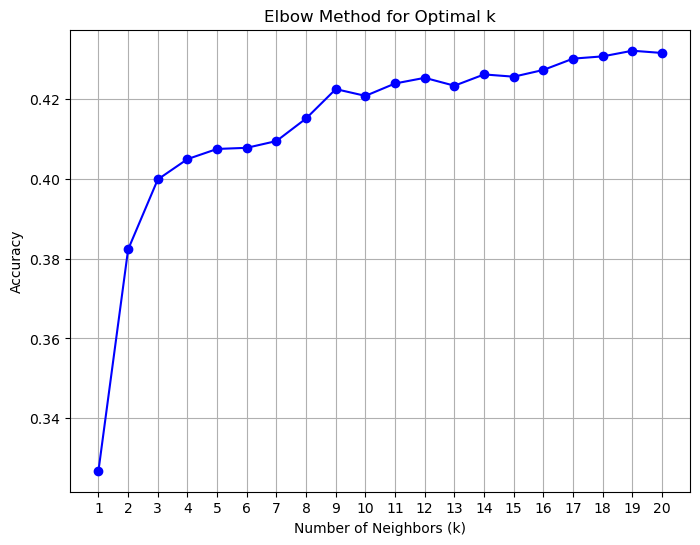

In [39]:
# Iterate through the k values
for k in k_values:
    # Train the KNN model with the current k
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Make predictions and calculate accuracy
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()




In [40]:
# Find the k with the highest accuracy
optimal_k = k_values[accuracies.index(max(accuracies))]
print(f"The optimal number of neighbors is: {optimal_k}")

The optimal number of neighbors is: 19


The optimal number of neighbors is: 19

In [41]:
# Preprocess the data
X = df_class_model.drop(['Date','Time','Code'], axis=1)
y = df_class_model['Min Delay']

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.40951571792693287
Classification Report:
              precision    recall  f1-score   support

         0.0       0.49      0.86      0.62      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.21      0.18      0.20       469
         4.0       0.14      0.07      0.10       368
         5.0       0.13      0.06      0.08       333
         6.0       0.21      0.04      0.07       187
         7.0       0.11      0.02      0.04       126
         8.0       0.12      0.03      0.04        75
         9.0       0.00      0.00      0.00        70
        10.0       0.00      0.00      0.00        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0       0.00      0.00      0.00        18
        17.0       0.00     

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

By applying the elbow method, the optimal K value for the KNN model using the Euclidean distance metric is determined to be 19.

With K=19, the model exhibits improved accuracy, precision, and recall.



Next, let's explore alternative distance metrics and utilize the elbow method to identify the optimal K value for each(euclidean distance, manhattan distance, minkowski distance).

In [42]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define a list of distance metrics to experiment with
metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:
    print(f"Training KNN model with {metric} distance...")

    # Train the KNN classifier with the selected metric
    knn = KNeighborsClassifier(n_neighbors=7, metric=metric)
    knn.fit(X_train, y_train)

    # Make predictions
    y_pred = knn.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy with {metric} distance: {accuracy}")
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    print('-' * 50)

Training KNN model with euclidean distance...
Accuracy with euclidean distance: 0.40951571792693287
Classification Report:
              precision    recall  f1-score   support

         0.0       0.49      0.86      0.62      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.21      0.18      0.20       469
         4.0       0.14      0.07      0.10       368
         5.0       0.13      0.06      0.08       333
         6.0       0.21      0.04      0.07       187
         7.0       0.11      0.02      0.04       126
         8.0       0.12      0.03      0.04        75
         9.0       0.00      0.00      0.00        70
        10.0       0.00      0.00      0.00        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

Accuracy with manhattan distance: 0.4440668365902011
Classification Report:
              precision    recall  f1-score   support

         0.0       0.52      0.91      0.66      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.24      0.23      0.24       469
         4.0       0.20      0.11      0.15       368
         5.0       0.17      0.08      0.11       333
         6.0       0.17      0.04      0.07       187
         7.0       0.11      0.02      0.04       126
         8.0       0.30      0.04      0.07        75
         9.0       0.00      0.00      0.00        70
        10.0       0.00      0.00      0.00        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0       0.00      0.00      0.00        18
     

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

Accuracy with minkowski distance: 0.40951571792693287
Classification Report:
              precision    recall  f1-score   support

         0.0       0.49      0.86      0.62      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.21      0.18      0.20       469
         4.0       0.14      0.07      0.10       368
         5.0       0.13      0.06      0.08       333
         6.0       0.21      0.04      0.07       187
         7.0       0.11      0.02      0.04       126
         8.0       0.12      0.03      0.04        75
         9.0       0.00      0.00      0.00        70
        10.0       0.00      0.00      0.00        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0       0.00      0.00      0.00        18
    

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

In [43]:
# Preprocess the data
X = df_class_model.drop(['Date','Time','Code'], axis=1)
y = df_class_model['Min Delay']

In [44]:
X

,Day,Station,Min Delay,Min Gap,Bound,Line,Month,Month Name,Category
0,Monday,VAUGHAN MC STATION,0.0,0.0,S,YU,1,January,Door/Passenger/Platform Incidents
1,Monday,BLOOR STATION,0.0,0.0,S,YU,1,January,Security/Policing
2,Monday,VAUGHAN MC STATION,8.0,14.0,S,YU,1,January,Miscellaneous
3,Monday,DUNDAS STATION,0.0,0.0,S,YU,1,January,Security/Policing
4,Monday,ST GEORGE YUS STATION,0.0,0.0,N,YU,1,January,Security/Policing
...,...,...,...,...,...,...,...,...,...
17648,Friday,BAYVIEW STATION,6.0,13.0,E,SHP,1,January,Mechanical/Electrical/Vehicle Equipment
17649,Friday,UNION STATION TO KING,4.0,8.0,N,YU,1,January,Door/Passenger/Platform Incidents
17650,Friday,PAPE STATION,9.0,14.0,E,BD,1,January,Security/Policing
17651,Friday,DAVISVILLE STATION,3.0,7.0,N,YU,1,January,Medical/Injury/Safety


Finding optimal K for Euclidean Distance, Manhattan Distance and Minkowski Distance in out KNN analysis.

Finding optimal k for euclidean distance...
Optimal k for euclidean distance: 19
Finding optimal k for manhattan distance...
Optimal k for manhattan distance: 18
Finding optimal k for minkowski distance...
Optimal k for minkowski distance: 19


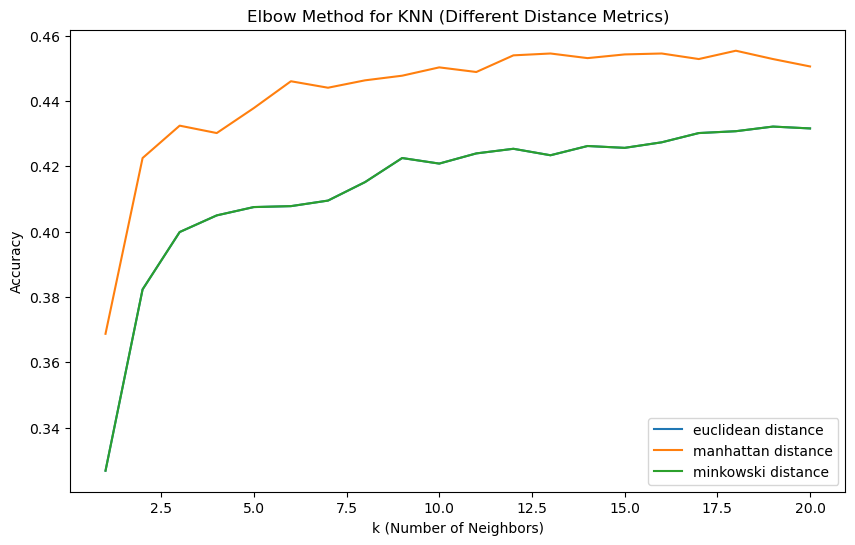

In [45]:

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the list of distance metrics to experiment with
metrics = ['euclidean', 'manhattan', 'minkowski']

# Create a plot to visualize the elbow method for each distance metric
plt.figure(figsize=(10, 6))

# Loop over each distance metric and apply the elbow method
for metric in metrics:
    print(f"Finding optimal k for {metric} distance...")
    
    # Initialize an empty list to store the accuracy for different k values
    accuracy_list = []
    k_values = range(1, 21)
    
    # Test different values of k (1 to 20)
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        accuracy = knn.score(X_test, y_test)
        accuracy_list.append(accuracy)
    
    # Plot accuracy for each k
    plt.plot(k_values, accuracy_list, label=f"{metric} distance")
    
    # Print the optimal k value for the current metric
    optimal_k = k_values[accuracy_list.index(max(accuracy_list))]
    print(f"Optimal k for {metric} distance: {optimal_k}")

# Add plot labels and title
plt.title('Elbow Method for KNN (Different Distance Metrics)')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The optimal K-value appears to be 19 for both the Euclidean and Minkowski distance metrics, while it is 18 for the Manhattan distance metric.

Among these, the Manhattan distance metric demonstrates the highest accuracy, surpassing the performance of the Euclidean metric initially used.


Next, let's apply normalization to our models in place of the standard scaler

Finding optimal k for euclidean gaps with Normalizer...
Optimal k for euclidean distance with Normalizer: 19
Finding optimal k for manhattan gaps with Normalizer...
Optimal k for manhattan distance with Normalizer: 17
Finding optimal k for minkowski gaps with Normalizer...
Optimal k for minkowski distance with Normalizer: 19


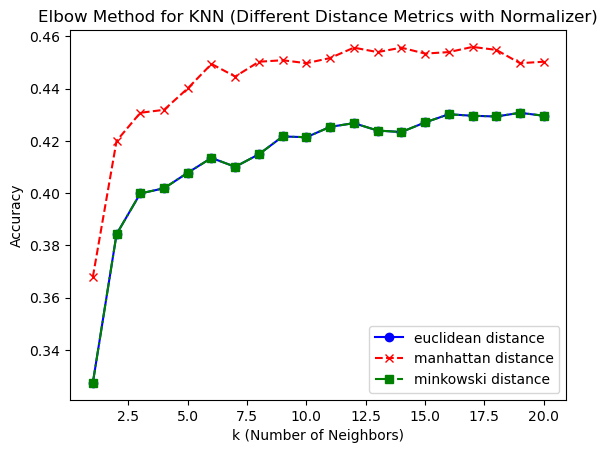

In [46]:
from sklearn.preprocessing import Normalizer

# Create the normalizer
normalizer = Normalizer()

# Loop over each distance metric and apply the elbow method with Normalizer
for metric in metrics:
    print(f"Finding optimal k for {metric} gaps with Normalizer...")

    # Initialize an empty list to store the accuracy for different k values
    accuracy_list = []
    k_values = range(1, 21)

    # Test different values of k (1 to 20)
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        # Apply normalization to the training and testing data
        X_train_norm = normalizer.fit_transform(X_train)
        X_test_norm = normalizer.transform(X_test)
        
        # Train the model
        knn.fit(X_train_norm, y_train)
        accuracy = knn.score(X_test_norm, y_test)
        accuracy_list.append(accuracy)
    
    # Plot accuracy for each k with customized style
    if metric == 'euclidean':
        plt.plot(k_values, accuracy_list, label=f"{metric} distance", color='blue', linestyle='-', marker='o')  # Blue color, solid line, circle markers
    elif metric == 'manhattan':
        plt.plot(k_values, accuracy_list, label=f"{metric} distance", color='red', linestyle='--', marker='x')  # Red color, dashed line, x markers
    else:
        plt.plot(k_values, accuracy_list, label=f"{metric} distance", color='green', linestyle='-.', marker='s')  # Green color, dash-dot line, square markers

    # Print the optimal k value for the current metric
    optimal_k = k_values[accuracy_list.index(max(accuracy_list))]
    print(f"Optimal k for {metric} distance with Normalizer: {optimal_k}")

# Add plot labels and title
plt.title('Elbow Method for KNN (Different Distance Metrics with Normalizer)')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [286]:
from sklearn.metrics import classification_report

# Set the optimal k values as specified
k_values = {
    'euclidean': 19,
    'manhattan': 17,
    'minkowski': 19
}

# Initialize the normalizer
normalizer = Normalizer()

# Loop over each distance metric and run the KNN models
for metric in ['euclidean', 'manhattan', 'minkowski']:
    print(f"Running KNN with {metric} metric...")
    
    # Initialize the KNN classifier with the selected k value for the current metric
    knn = KNeighborsClassifier(n_neighbors=k_values[metric], metric=metric)

    # Normalize the training and testing data
    X_train_norm = normalizer.fit_transform(X_train)
    X_test_norm = normalizer.transform(X_test)
    
    # Train the model
    knn.fit(X_train_norm, y_train)

    # Make predictions
    y_pred = knn.predict(X_test_norm)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy for {metric}: {accuracy:.4f}')
    print(f"Classification Report for {metric}:")
    print(classification_report(y_test, y_pred))
    print("="*50)

Running KNN with euclidean metric...
Accuracy for euclidean: 0.4308
Classification Report for euclidean:
              precision    recall  f1-score   support

         0.0       0.47      0.94      0.63      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.21      0.11      0.15       469
         4.0       0.19      0.06      0.09       368
         5.0       0.15      0.05      0.07       333
         6.0       0.26      0.03      0.05       187
         7.0       0.00      0.00      0.00       126
         8.0       0.22      0.03      0.05        75
         9.0       0.00      0.00      0.00        70
        10.0       0.00      0.00      0.00        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0       0.00      0

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

Accuracy for manhattan: 0.4560
Classification Report for manhattan:
              precision    recall  f1-score   support

         0.0       0.50      0.96      0.66      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.25      0.17      0.21       469
         4.0       0.25      0.08      0.13       368
         5.0       0.21      0.08      0.11       333
         6.0       0.32      0.05      0.08       187
         7.0       0.20      0.02      0.03       126
         8.0       0.33      0.03      0.05        75
         9.0       0.00      0.00      0.00        70
        10.0       1.00      0.03      0.06        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0       0.00      0.00      0.00        18
        17.0 

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

Accuracy for minkowski: 0.4308
Classification Report for minkowski:
              precision    recall  f1-score   support

         0.0       0.47      0.94      0.63      1520
         2.0       0.00      0.00      0.00         4
         3.0       0.21      0.11      0.15       469
         4.0       0.19      0.06      0.09       368
         5.0       0.15      0.05      0.07       333
         6.0       0.26      0.03      0.05       187
         7.0       0.00      0.00      0.00       126
         8.0       0.22      0.03      0.05        75
         9.0       0.00      0.00      0.00        70
        10.0       0.00      0.00      0.00        69
        11.0       0.00      0.00      0.00        34
        12.0       0.00      0.00      0.00        36
        13.0       0.00      0.00      0.00        28
        14.0       0.00      0.00      0.00        22
        15.0       0.00      0.00      0.00        25
        16.0       0.00      0.00      0.00        18
        17.0 

c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

The conclusion:
The StandardScaler is showing better F1 score than normalization technique. 
To improve the model performance we should stick with StandardScaler model and with the Manhattan distance metric, K=17, achieving an accuracy of 0.4560